
This line is to run py 3.11 version on colab beacuse pycaret runs on version 3.11 or lower

In [2]:
!pip install pycaret -q

import re
import os

# Direct path to the PyCaret init file in Colab
init_path = '/usr/local/lib/python3.12/dist-packages/pycaret/__init__.py'

if os.path.exists(init_path):
    with open(init_path, 'r') as f:
        content = f.read()

    # Remove the block that raises RuntimeError on Python 3.12
    new_content = re.sub(
        r'elif sys\.version_info >= \(3, 12\):.*?raise RuntimeError\(.*?\)',
        '',
        content,
        flags=re.DOTALL
    )

    with open(init_path, 'w') as f:
        f.write(new_content)

    print('✅ PyCaret version check removed!')
    print('⚠️ Now Restart Session (Runtime > Restart session) and then run your imports.')
else:
    print('❌ PyCaret not found. Ensure it is installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/fraud_model_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)
print('✅ Drive mounted! Checkpoint folder ready:', SAVE_DIR)

Mounted at /content/drive
✅ Drive mounted! Checkpoint folder ready: /content/drive/MyDrive/fraud_model_checkpoints


## 1. Install & Import

In [4]:
import pandas as pd
import numpy as np
from pycaret.classification import *

## 2. Load Data

In [5]:
# Update paths to where your CSVs are stored on Drive
train_df = pd.read_csv('/content/drive/MyDrive/fraud_model_checkpoints/FraudTrain.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/fraud_model_checkpoints/FraudTest.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (1296675, 23)
Test shape:  (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 3. Feature Engineering
Same features as the original notebook: hour, age, distance.

In [6]:
def engineer_features(df):
    df = df.copy()

    # Drop irrelevant columns
    cols_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # Extract hour from transaction datetime
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df = df.drop(columns=['trans_date_trans_time'])

    # Age from date of birth
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = 2026 - df['dob'].dt.year
    df = df.drop(columns=['dob'])

    # Distance between customer and merchant (fraud often = far away)
    df['distance'] = np.sqrt(
        (df['lat'] - df['merch_lat'])**2 +
        (df['long'] - df['merch_long'])**2
    )

    # Reset index to avoid duplicate index errors in PyCaret
    df = df.reset_index(drop=True)

    return df

train_df = engineer_features(train_df)
test_df  = engineer_features(test_df)

print('✅ Feature engineering done!')
print('Columns:', list(train_df.columns))
print('Fraud rate: {:.2f}%'.format(train_df['is_fraud'].mean() * 100))

✅ Feature engineering done!
Columns: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'age', 'distance']
Fraud rate: 0.58%


## 4. PyCaret Setup
PyCaret automatically handles:
-  Label encoding of categorical columns
-  StandardScaler normalization
- SMOTE for class imbalance
-  Train/validation splitting

In [7]:
train_df.dropna(subset=['is_fraud'], inplace=True)
clf = setup(
    data            = train_df,
    target          = 'is_fraud',
    test_data       = test_df,
    index           = False,

    use_gpu= True,
    # Preprocessing
    normalize       = True,
    fix_imbalance   = True,

    # Categorical columns
    categorical_features = ['merchant', 'category', 'gender', 'city', 'state', 'job'],

    # Evaluation
    fold            = 5,
    session_id      = 42,
    verbose         = True
)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset migh

,Description,Value
0,Session id,42
1,Target,is_fraud
2,Target type,Binary
3,Original data shape,"(1852394, 18)"
4,Transformed data shape,"(3134057, 31)"
5,Transformed train set shape,"(2578338, 31)"
6,Transformed test set shape,"(555719, 31)"
7,Numeric features,11
8,Categorical features,6
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset migh

In [26]:
# Let's verify that the 'is_fraud' column is still there and see the class distribution
print(f"Target column exists: {'is_fraud' in train_df.columns}")
print("\nClass counts in training data:")
display(train_df['is_fraud'].value_counts())

Target column exists: True

Class counts in training data:


,count
is_fraud,
0,1289169
1,7506


## 5. Compare All Models
`compare_models()` trains and cross-validates every available classifier and ranks them — no manual loop needed.

In [27]:
best_models = compare_models(
    include  = ['xgboost', 'lightgbm'],   # GPU-compatible models only
    sort     = 'AUC',
    n_select = 2                           # return top 2
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9359,0.9011,0.2826,0.4672,0.1782,0.1746,0.2381,28.2020
lightgbm,Light Gradient Boosting Machine,0.9478,0.7245,0.1719,0.3157,0.1714,0.1672,0.1900,44.3300


Processing:   0%|          | 0/14 [00:00<?, ?it/s]

## 6. Train  Models


In [28]:
model_xgb = create_model(
    'xgboost',
    n_estimators  = 100,
    learning_rate = 0.01,
    tree_method   = 'hist',   # ← Changed from 'gpu_hist' to 'hist'
    device        = 'cuda',       # ← use T4 GPU
    fold          = 5
)
print('✅ XGBoost training done!')


model_lgbm = create_model(
    'lightgbm',
    n_estimators  = 100,
    learning_rate = 0.01,
    device        = 'gpu',        # ← GPU acceleration
    fold          = 5
)
print('✅ LightGBM training done!')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3151,0.5670,0.9947,0.0083,0.0165,0.0051,0.0502
1,0.9703,0.4236,0.1339,0.0304,0.0496,0.0405,0.0525
2,0.9704,0.2324,0.1592,0.0359,0.0586,0.0497,0.0645
3,0.9716,0.2935,0.1499,0.0356,0.0575,0.0486,0.0621
4,0.9693,0.4427,0.1778,0.0382,0.0629,0.0539,0.0711
Mean,0.8393,0.3918,0.3231,0.0297,0.0490,0.0396,0.0601
Std,0.2621,0.1178,0.3361,0.0110,0.0168,0.0178,0.0077


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

✅ XGBoost training done!


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3780,0.3954,0.4710,0.0044,0.0087,-0.0028,-0.0237
1,0.9793,0.4895,0.1346,0.0474,0.0701,0.0621,0.0709
2,0.9768,0.4655,0.1606,0.0482,0.0741,0.0658,0.0784
3,0.9789,0.5126,0.1506,0.0511,0.0763,0.0682,0.0786
4,0.9800,0.5040,0.1724,0.0616,0.0908,0.0830,0.0944
Mean,0.8586,0.4734,0.2178,0.0425,0.0640,0.0553,0.0597
Std,0.2403,0.0421,0.1272,0.0197,0.0285,0.0299,0.0424


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

✅ LightGBM training done!


## 7. Evaluate Models
PyCaret plots confusion matrix, ROC curve, feature importance — all in one call.

In [29]:
print('===== XGBoost Evaluation =====')
evaluate_model(model_xgb)

===== XGBoost Evaluation =====


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [30]:
print('===== LightGBM Evaluation =====')
evaluate_model(model_lgbm)

===== LightGBM Evaluation =====


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## 8. Detailed Plots

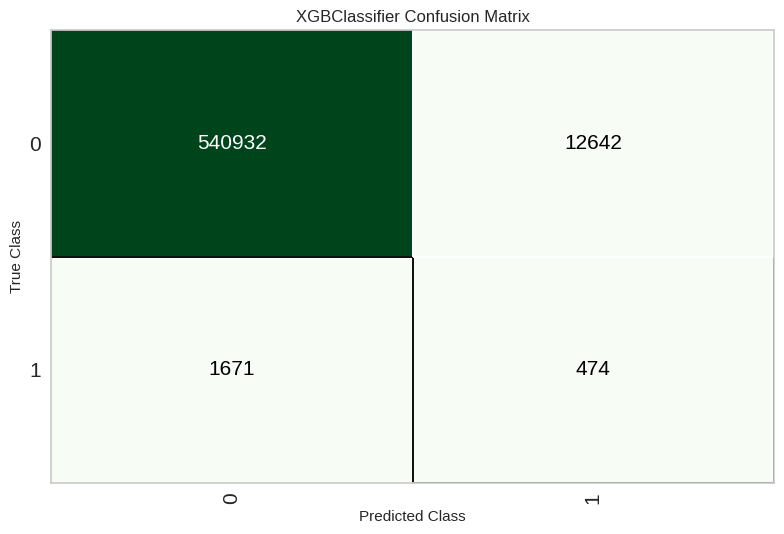

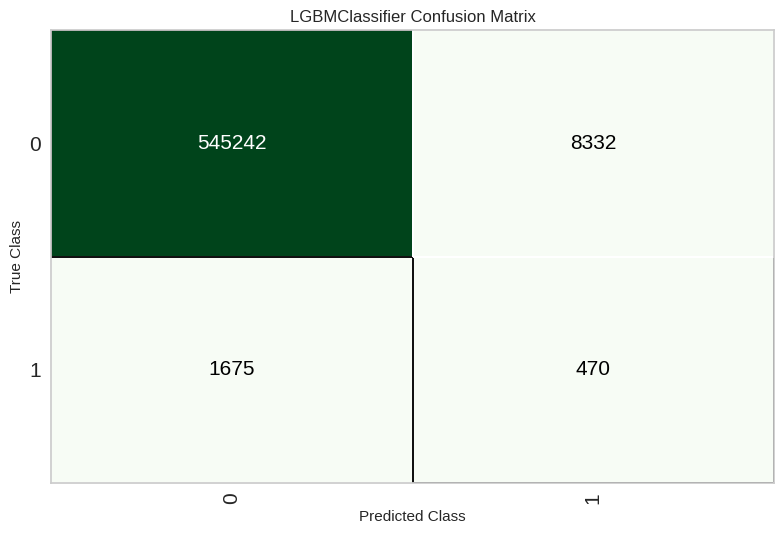

In [31]:
# Confusion Matrix
plot_model(model_xgb,  plot='confusion_matrix')
plot_model(model_lgbm, plot='confusion_matrix')

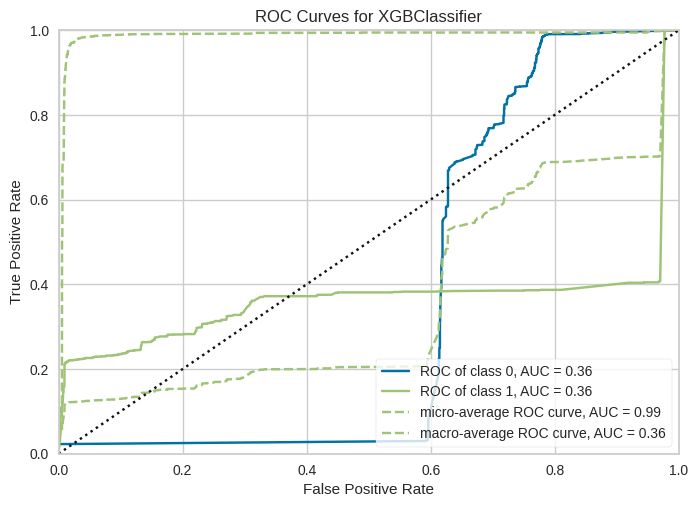

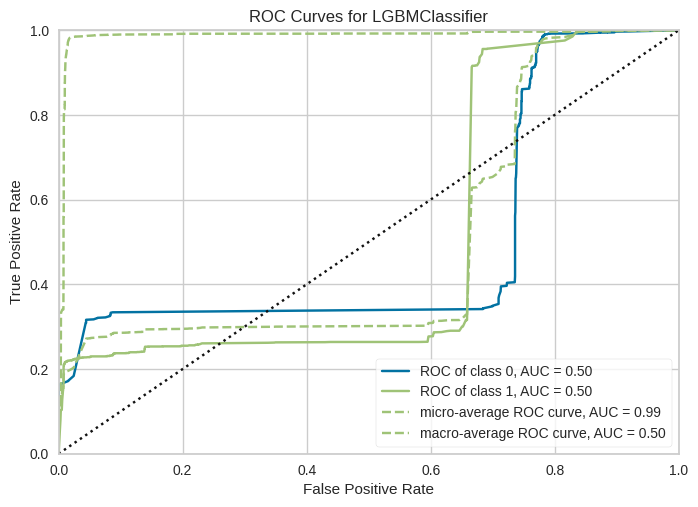

In [32]:
# ROC Curve
plot_model(model_xgb,  plot='auc')
plot_model(model_lgbm, plot='auc')

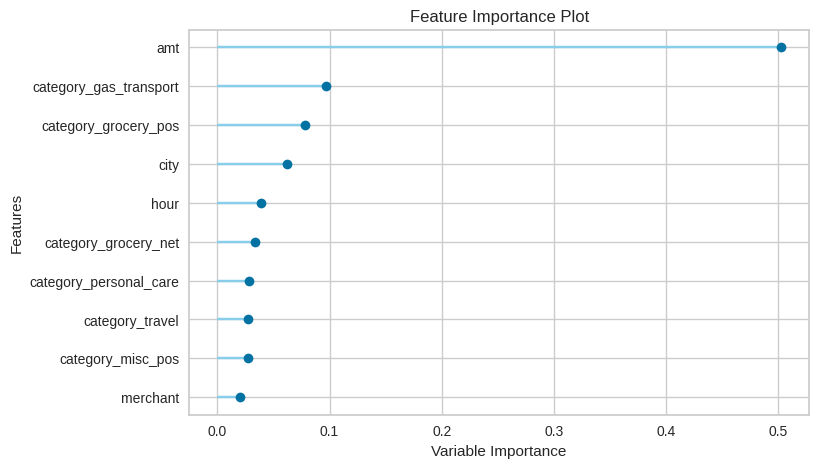

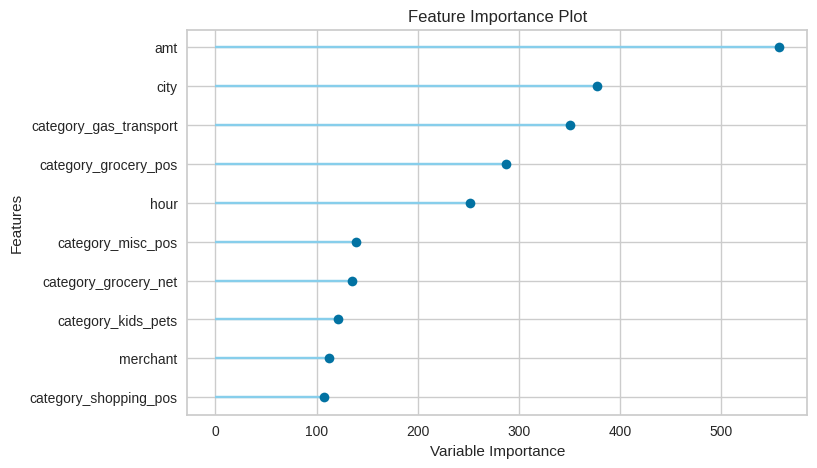

In [33]:
# Feature Importance
plot_model(model_xgb, plot='feature')
plot_model(model_lgbm, plot='feature')

## 9. Predict on Test Set

In [34]:
# Finalize = retrain on full data (train + validation combined)
final_xgb  = finalize_model(model_xgb)
final_lgbm = finalize_model(model_lgbm)

# Predict on held-out test set
pred_xgb  = predict_model(final_xgb,  data=test_df)
pred_lgbm = predict_model(final_lgbm, data=test_df)

print('XGBoost predictions:')
print(pred_xgb[['prediction_label', 'prediction_score']].head(10))

print('\nLightGBM predictions:')
print(pred_lgbm[['prediction_label', 'prediction_score']].head(10))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9812,0.9755,0.8406,0.1517,0.2570,0.2521,0.3524


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9845,0.9715,0.8121,0.1753,0.2883,0.2838,0.3731


XGBoost predictions:
   prediction_label  prediction_score
0                 0            0.8008
1                 0            0.7996
2                 0            0.7991
3                 0            0.7783
4                 0            0.8004
5                 0            0.7974
6                 0            0.7649
7                 0            0.7996
8                 0            0.8004
9                 0            0.7991

LightGBM predictions:
   prediction_label  prediction_score
0                 0            0.7984
1                 0            0.7984
2                 0            0.7984
3                 0            0.7989
4                 0            0.7984
5                 0            0.7984
6                 0            0.7786
7                 0            0.7984
8                 0            0.7984
9                 0            0.7984


## 10. Save Models to Google Drive
So you never need to retrain after a Colab disconnect.

In [35]:
save_model(final_xgb,  f'{SAVE_DIR}/xgb_model')
save_model(final_lgbm, f'{SAVE_DIR}/lgbm_model')
print(' Both models saved to Google Drive!')
print(f'Location: {SAVE_DIR}')

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
 Both models saved to Google Drive!
Location: /content/drive/MyDrive/fraud_model_checkpoints


## 11. Load Models After Disconnect
Run this cell instead of retraining after a Colab disconnect.

In [2]:
# ─── RUN THIS AFTER A DISCONNECT INSTEAD OF RETRAINING ───
from pycaret.classification import load_model, predict_model
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/fraud_model_checkpoints'

loaded_xgb  = load_model(f'{SAVE_DIR}/xgb_model')
loaded_lgbm = load_model(f'{SAVE_DIR}/lgbm_model')

print('✅ Models loaded from Drive! Ready to predict.')

Mounted at /content/drive
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
✅ Models loaded from Drive! Ready to predict.
